In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2

In [2]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   
    

In [3]:
image = cv2.imread('../notebooks/images/truck.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

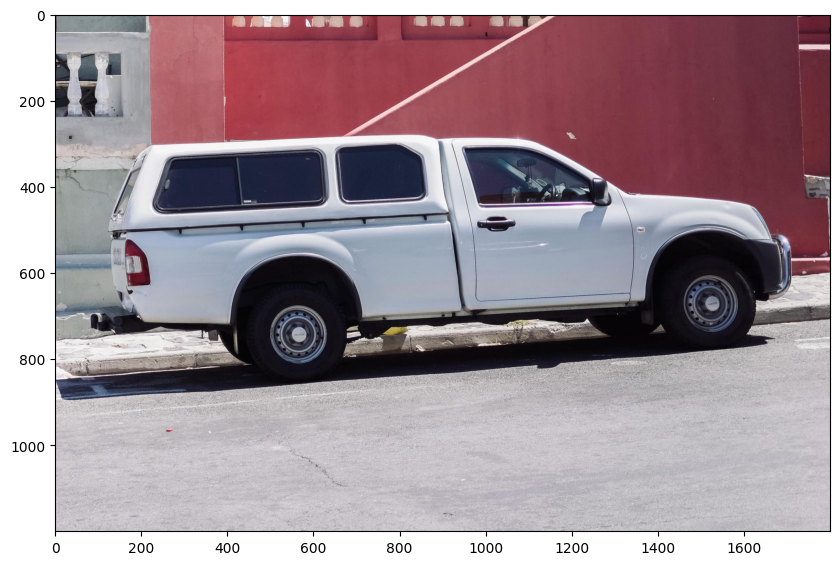

In [4]:
plt.figure(figsize=(10,10))
plt.imshow(image)
plt.axis('on')
plt.show()

In [5]:
import onnx
import coremltools as ct

import sys
sys.path.append("..")

# model_path = "../weights/edge_sam_10x_encoder.onnx"
encoder_model_path = "../weights/edge_sam_3x_encoder.mlpackage"

Minimum required torch version for importing coremltools.optimize.torch is 2.1.0. Got torch version 2.0.0.


In [6]:
image[0]

array([[ 67,  48,  54],
       [ 57,  42,  47],
       [ 51,  45,  47],
       ...,
       [103,  36,  53],
       [103,  36,  53],
       [104,  37,  54]], dtype=uint8)

In [7]:
encoder_model = ct.models.MLModel(encoder_model_path)
print(encoder_model.input_description)
print(encoder_model.output_description)

Features(image)
Features(image_embeddings)


In [8]:
decoder_model_path = "../weights/edge_sam_3x_decoder.mlpackage"
decoder_model = ct.models.MLModel(decoder_model_path)
print(decoder_model.input_description)
print(decoder_model.output_description)

Features(image_embeddings,point_coords,point_labels)
Features(scores,masks)


In [9]:
# image = cv2.resize(image, (1024, 1024))  # resize to match model input


In [10]:
image = cv2.imread('../notebooks/images/truck.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_height, image_width = image.shape[:2]

print("image_height, image_width", image_height, image_width)

image = cv2.resize(image, (1024, 1024))
# Normalize and transpose to (1, 3, H, W)
# image_input = image.astype(np.float32) / 255.0
#image_input = image_input.transpose(2, 0, 1)  # HWC → CHW
#image_input = np.expand_dims(image_input, axis=0)  # Add batch dim

image_height, image_width 1200 1800


In [11]:
input_point_normalized = np.array([[500/image_width, 375/image_height]])  # in pixel coords
print(input_point_normalized)
input_point = input_point_normalized * np.array([1024, 1024])
# input_point = input_point_normalized * np.array([image_width, image_height])

# Reshape to (1, N, 2)
point_coords = input_point[np.newaxis, :, :]  # shape: [1, N, 2]


point_labels = np.array([1])  # e.g., positive point
# Reshape to (1, N)
point_labels = point_labels[np.newaxis, :]           # shape: (1, 1)
print(point_labels)

[[0.27777778 0.3125    ]]
[[1]]


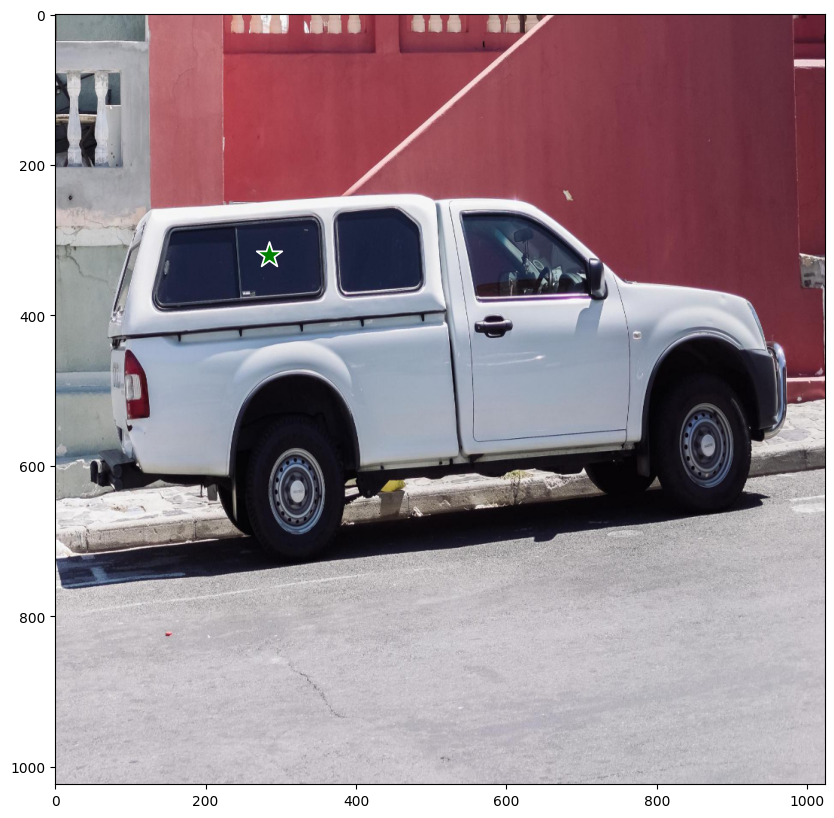

In [12]:
plt.figure(figsize=(10,10))
plt.imshow(image)
show_points(point_coords, point_labels, plt.gca())
plt.axis('on')
plt.show()

In [13]:
# image_input[0]

In [14]:
#image_input.shape

In [15]:
image = cv2.imread('../notebooks/images/truck.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_height, image_width = image.shape[:2]

print("image_height, image_width", image_height, image_width)

image = cv2.resize(image, (1024, 1024))

# Normalize and transpose to (1, 3, H, W)
# https://github.com/evannwolfe/Segment-Anything-CPP-iOS-Wrapper/blob/main/sam.cpp#L167-L169
image_input_normalized = image.astype(np.float32) / 255.0
print(image_input_normalized.shape)


image_input_transposed = image_input_normalized.transpose(2, 0, 1)  # HWC → CHW
image_input_expanded = np.expand_dims(image_input_transposed, axis=0)  # Add batch dim
print("image_input_expanded.shape",image_input_expanded.shape)

image_height, image_width 1200 1800
(1024, 1024, 3)
image_input_expanded.shape (1, 3, 1024, 1024)


In [16]:
#print(image_input_expanded)
print(image_input_expanded.shape)
print(
    image_input_expanded[0][0][0][0],
    image_input_expanded[0][0][0][1],
    image_input_expanded[0][0][0][2],
    image_input_expanded[0][0][0][3],
)
print(
    image_input_expanded[0][0][0][0],
    image_input_expanded[0][1][0][0],
    image_input_expanded[0][2][0][0],
)

(1, 3, 1024, 1024)
0.24705882 0.2509804 0.5568628 0.5372549
0.24705882 0.18039216 0.2


In [17]:

print(image_input_expanded.shape)
print(
    image_input_expanded[0][1][0][0],
    image_input_expanded[0][1][0][1],
    image_input_expanded[0][1][0][2],
    image_input_expanded[0][1][0][3],
)
print(
    image_input_expanded[0][0][0][500],
    image_input_expanded[0][1][0][500],
    image_input_expanded[0][2][0][500],
)

(1, 3, 1024, 1024)
0.18039216 0.23529412 0.59607846 0.6039216
0.85490197 0.7254902 0.6862745


In [18]:
encoder_inputs = {
    "image": image_input_expanded,
}

encoder_output = encoder_model.predict(encoder_inputs)

In [19]:
encoder_output['image_embeddings'].shape

(1, 256, 64, 64)

In [20]:
print(
    encoder_output['image_embeddings'][0][0][0][0],
    encoder_output['image_embeddings'][0][0][0][1],
    encoder_output['image_embeddings'][0][0][0][2],
    encoder_output['image_embeddings'][0][0][0][3],
    encoder_output['image_embeddings'][0][0][0][4],
)

-0.28466797 -0.24316406 -0.18847656 -0.08282471 -0.0262146


In [22]:
print(
    encoder_output['image_embeddings'][0][0][0][0],
    encoder_output['image_embeddings'][0][1][0][0],
    encoder_output['image_embeddings'][0][2][0][0],
)

-0.28466797 -0.13903809 -0.15002441


In [21]:
encoder_output['image_embeddings']

array([[[[-0.28466797, -0.24316406, -0.18847656, ..., -0.13867188,
          -0.36450195, -0.3317871 ],
         [-0.43041992, -0.3659668 , -0.27197266, ..., -0.42333984,
          -0.48608398, -0.51953125],
         [-0.3334961 , -0.28149414, -0.21484375, ..., -0.39819336,
          -0.21105957, -0.17687988],
         ...,
         [-0.35205078, -0.4020996 , -0.37036133, ..., -0.23461914,
          -0.19274902, -0.35766602],
         [-0.31396484, -0.38476562, -0.3959961 , ..., -0.20373535,
          -0.24511719, -0.3774414 ],
         [-0.30639648, -0.3540039 , -0.36645508, ..., -0.26171875,
          -0.29345703, -0.3647461 ]],

        [[-0.13903809, -0.1973877 , -0.20080566, ..., -0.19189453,
          -0.0329895 , -0.11773682],
         [-0.00626755, -0.08911133, -0.03762817, ..., -0.14001465,
           0.03167725,  0.1505127 ],
         [-0.07769775, -0.14758301, -0.13378906, ..., -0.06994629,
          -0.06130981,  0.07366943],
         ...,
         [-0.08929443, -0.20349121

In [19]:
#decoder_model.get_spec().description.input

In [20]:
point_coords

array([[[284.44444444, 320.        ]]])

In [36]:
#input_point_normalized = np.array([[500/image_width, 375/image_height]])  # in pixel coords
#input_point = input_point_normalized * np.array([1024, 1024])  # normalize
#point_coords = input_point[np.newaxis, :, :]  # shape: [1, N, 2]

#point_labels = np.array([1])  # e.g., positive point
#point_labels = point_labels[np.newaxis, :]           # shape: (1, 1)
#print(point_labels)

print("input_point_normalized",input_point_normalized)

input_point_decoder = input_point_normalized * np.array([1024, 1024])
print("input_point_decoder",input_point_decoder)

point_coords_decoder = input_point_decoder[np.newaxis, :, :]

input_label = np.array([1])

print("point_labels", point_labels)

input_point_normalized [[0.27777778 0.3125    ]]
input_point_decoder [[284.44444444 320.        ]]
point_labels [[1]]


[0.9742229 0.9723926 0.9807122 0.7385589]
(4, 256, 256)


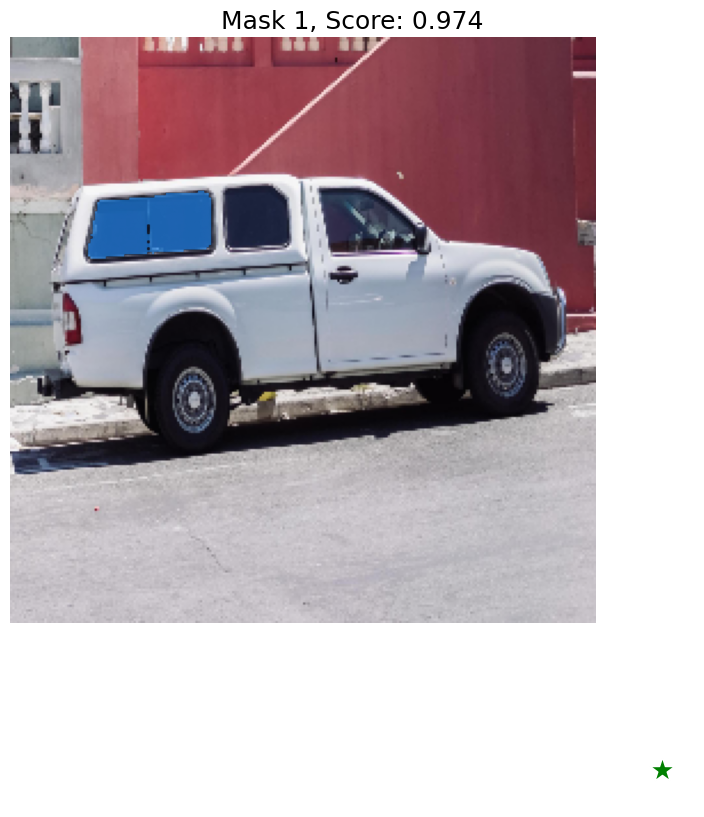

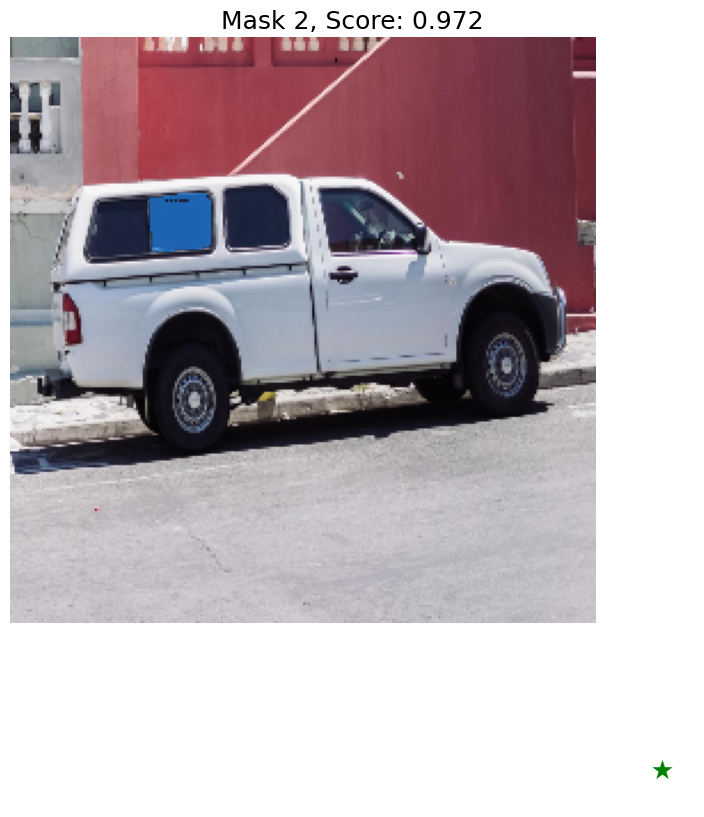

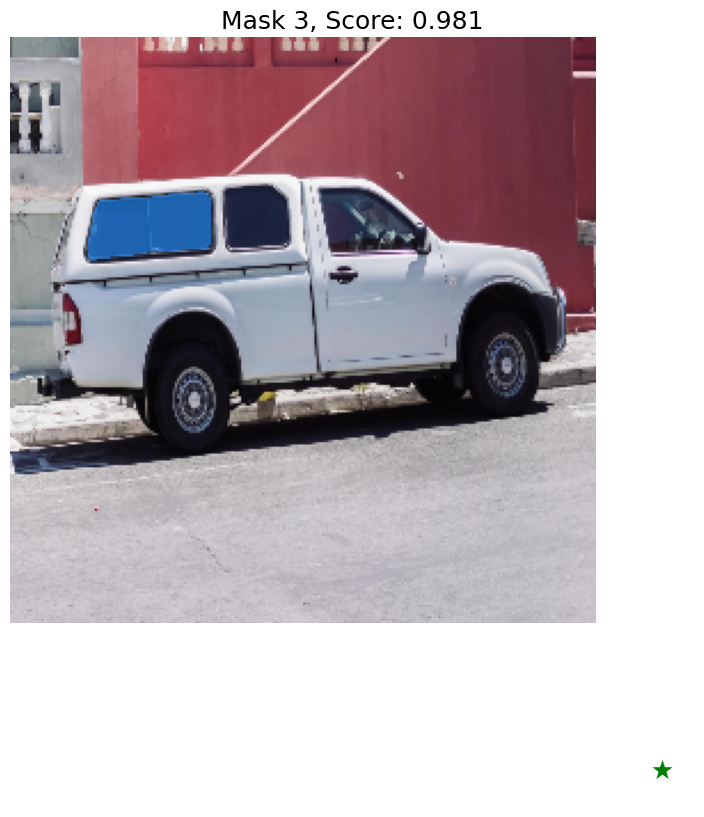

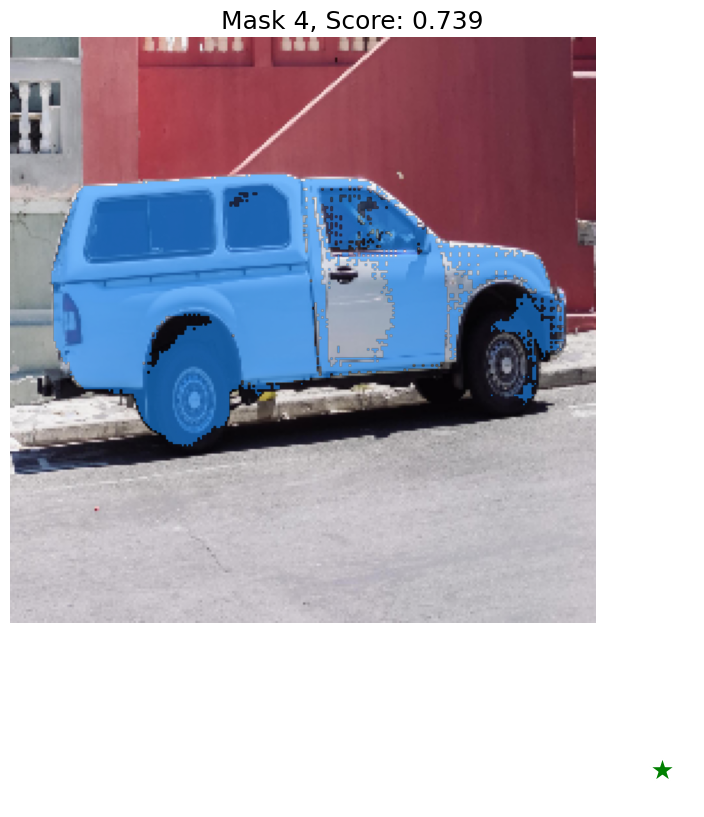

In [54]:
decoder_inputs = {
    "image_embeddings": encoder_output["image_embeddings"].astype(np.float32),
    "point_coords": point_coords_decoder.astype(np.float32),
    "point_labels": point_labels.astype(np.float32),
}
decoder_output = decoder_model.predict(decoder_inputs)

scores = decoder_output['scores'][0]
print(scores)

raw_logits = np.squeeze(decoder_output['masks'], axis=0)
bool_masks = raw_logits > 0
print(bool_masks.shape)

resized = cv2.resize(image, (256,256))

for i, (mask, score) in enumerate(zip(bool_masks, scores)):
    plt.figure(figsize=(10,10))
    plt.imshow(resized)
    show_mask(mask, plt.gca())
    show_points(input_point_decoder, input_label, plt.gca())
    plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
    plt.axis('off')
    plt.show()  

In [111]:
#

In [104]:
decoder_output['masks'].shape

(1, 4, 256, 256)

In [106]:
raw_logits = np.squeeze(decoder_output['masks'], axis=0)
bool_masks = raw_logits > 0
bool_masks.shape

(4, 256, 256)

In [100]:
scores = decoder_output['scores'][0]

In [101]:
#input_point = np.array([[500/1024*256, 375/1024*256]], dtype=np.float32)


resized = cv2.resize(image, (256,256))

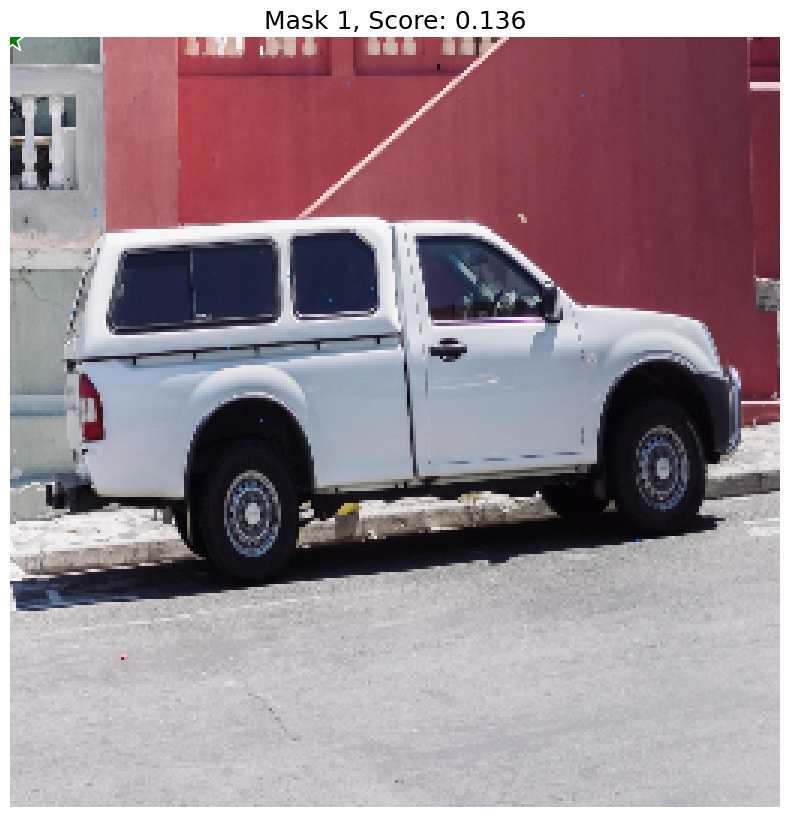

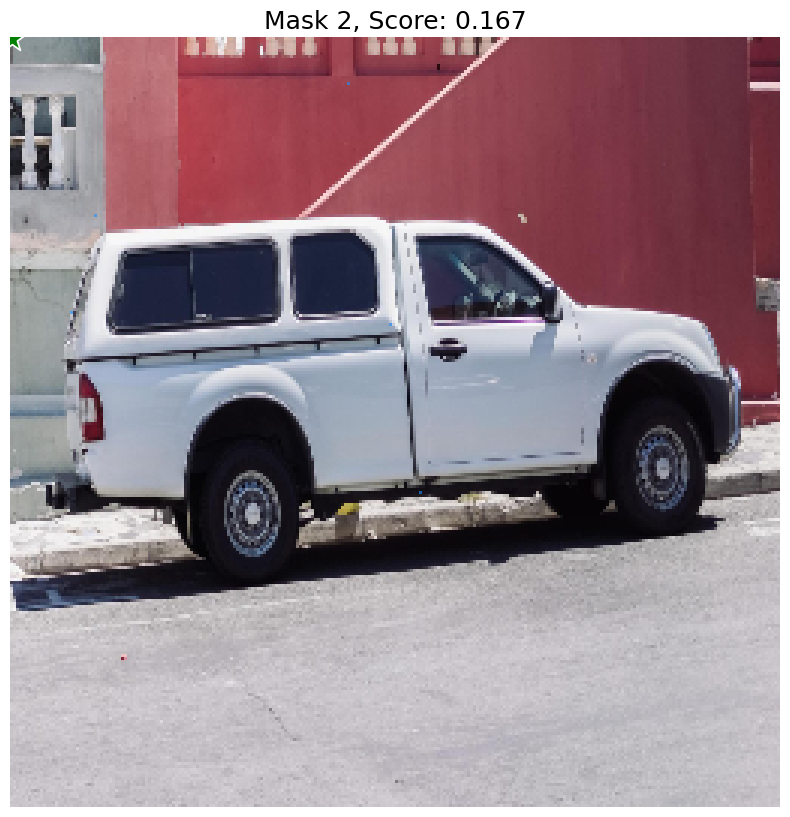

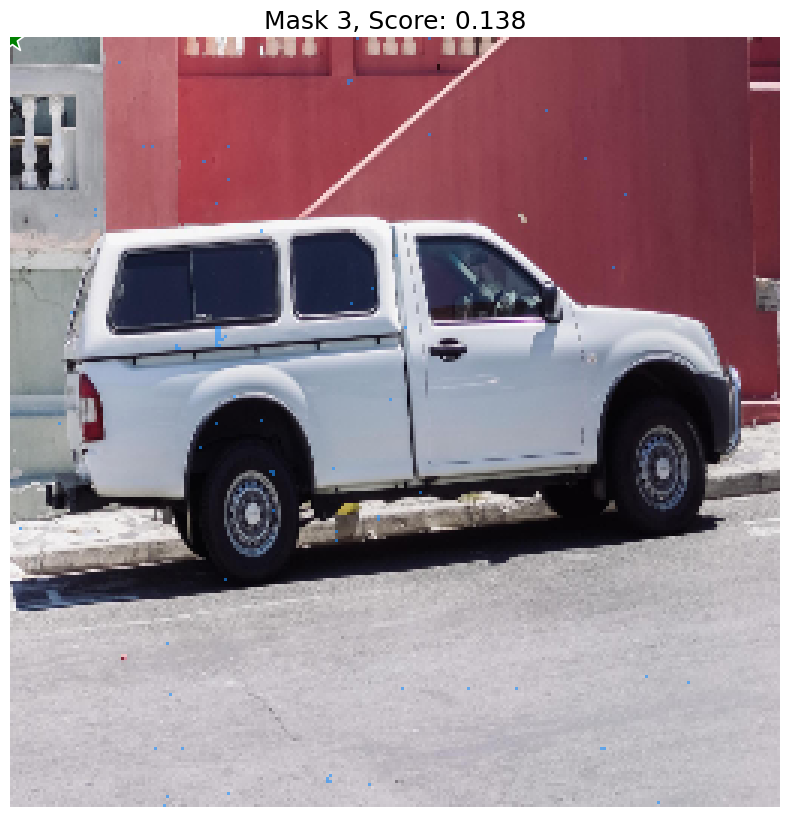

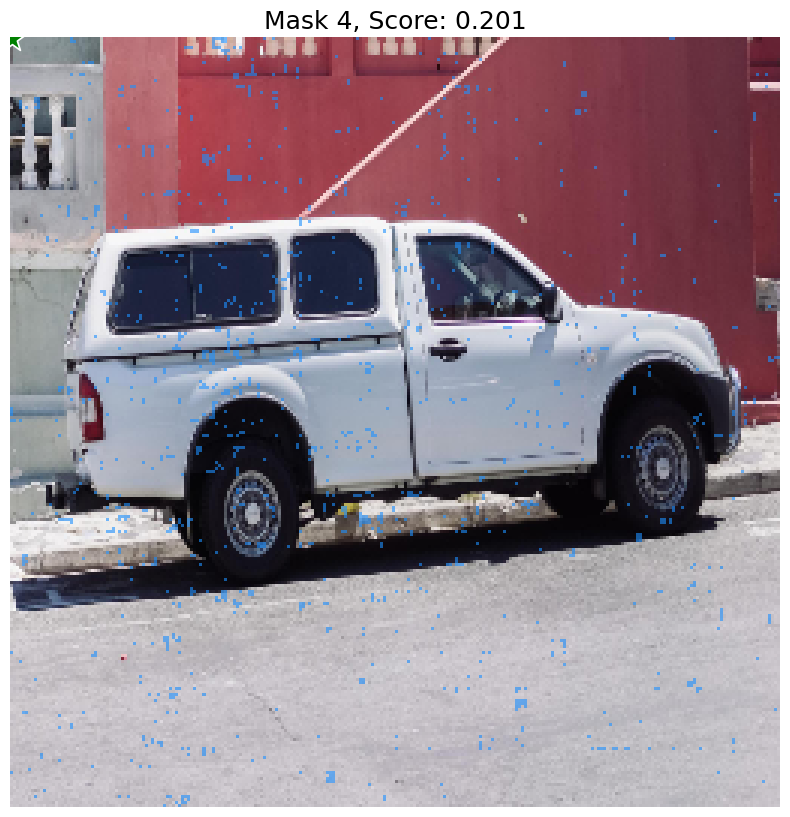

In [102]:
for i, (mask, score) in enumerate(zip(bool_masks, scores)):
    plt.figure(figsize=(10,10))
    plt.imshow(resized)
    show_mask(mask, plt.gca())
    show_points(input_point_decoder, input_label, plt.gca())
    plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
    plt.axis('off')
    plt.show()  

In [4]:

# Convert to Core ML
coreml_model = ct.converters.onnx.convert(model=onnx_model)

AttributeError: module 'coremltools.converters' has no attribute 'onnx'

In [ ]:

# Convert to Core ML
coreml_model = ct.converters.onnx.convert(model=onnx_model)

# Save the Core ML model
coreml_model.save("model.mlmodel")
